In [2]:
with open("HDFS_2k.log") as f:
    for _ in range(5):
        print(f.readline())


FileNotFoundError: [Errno 2] No such file or directory: 'HDFS_2k.log'

In [1]:
import os
os.makedirs("data/hdfs", exist_ok=True)


In [2]:
import requests

url = "https://raw.githubusercontent.com/logpai/loghub/master/HDFS/HDFS_2k.log"
path = "data/hdfs/HDFS_2k.log"

r = requests.get(url)
with open(path, "wb") as f:
    f.write(r.content)

print("Downloaded:", path)


Downloaded: data/hdfs/HDFS_2k.log


In [3]:
url = "https://raw.githubusercontent.com/logpai/loghub/master/HDFS/HDFS_2k.log_structured.csv"
path = "data/hdfs/HDFS_2k.log_structured.csv"

r = requests.get(url)
with open(path, "wb") as f:
    f.write(r.content)

print("Downloaded:", path)


Downloaded: data/hdfs/HDFS_2k.log_structured.csv


In [4]:
os.listdir("data/hdfs")


['HDFS_2k.log', 'HDFS_2k.log_structured.csv']

In [5]:
with open("data/hdfs/HDFS_2k.log") as f:
    for _ in range(5):
        print(f.readline())

081109 203615 148 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_38865049064139660 terminating

081109 203807 222 INFO dfs.DataNode$PacketResponder: PacketResponder 0 for block blk_-6952295868487656571 terminating

081109 204005 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 67108864

081109 204015 308 INFO dfs.DataNode$PacketResponder: PacketResponder 2 for block blk_8229193803249955061 terminating

081109 204106 329 INFO dfs.DataNode$PacketResponder: PacketResponder 2 for block blk_-6670958622368987959 terminating



In [3]:
import pandas as pd

df = pd.read_csv("data/hdfs/HDFS_2k.log_structured.csv")
print(df.head())
print()
print()
print(df.shape)
print()
print(df.size)
print( )
print(df.describe())


   LineId   Date    Time  Pid Level                     Component  \
0       1  81109  203615  148  INFO  dfs.DataNode$PacketResponder   
1       2  81109  203807  222  INFO  dfs.DataNode$PacketResponder   
2       3  81109  204005   35  INFO              dfs.FSNamesystem   
3       4  81109  204015  308  INFO  dfs.DataNode$PacketResponder   
4       5  81109  204106  329  INFO  dfs.DataNode$PacketResponder   

                                             Content EventId  \
0  PacketResponder 1 for block blk_38865049064139...     E10   
1  PacketResponder 0 for block blk_-6952295868487...     E10   
2  BLOCK* NameSystem.addStoredBlock: blockMap upd...      E6   
3  PacketResponder 2 for block blk_82291938032499...     E10   
4  PacketResponder 2 for block blk_-6670958622368...     E10   

                                       EventTemplate  
0  PacketResponder <*> for block blk_<*> terminating  
1  PacketResponder <*> for block blk_<*> terminating  
2  BLOCK* NameSystem.addStoredBlock

In [4]:
df.isnull().sum().sum()

0

In [5]:
df.columns

Index(['LineId', 'Date', 'Time', 'Pid', 'Level', 'Component', 'Content',
       'EventId', 'EventTemplate'],
      dtype='object')

In [6]:
corr = df.corr(numeric_only=True)
corr

,LineId,Date,Time,Pid
LineId,1.000000,0.885235,-0.287900,0.377551
Date,0.885235,1.000000,-0.667463,0.329515
Time,-0.287900,-0.667463,1.000000,-0.113762
Pid,0.377551,0.329515,-0.113762,1.000000


In [7]:
import pandas as pd
from sklearn.ensemble import IsolationForest
import json

In [8]:
df["BlockId"] = df["Content"].str.extract(r"(blk_-?\d+)")


In [9]:
df[["Content", "BlockId"]].head(5)


,Content,BlockId
0,PacketResponder 1 for block blk_38865049064139...,blk_38865049064139660
1,PacketResponder 0 for block blk_-6952295868487...,blk_-6952295868487656571
2,BLOCK* NameSystem.addStoredBlock: blockMap upd...,blk_7128370237687728475
3,PacketResponder 2 for block blk_82291938032499...,blk_8229193803249955061
4,PacketResponder 2 for block blk_-6670958622368...,blk_-6670958622368987959


In [10]:
df = df.dropna(subset=["BlockId"])


In [11]:
X = pd.crosstab(
    df["BlockId"],
    df["EventId"]
)


In [12]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

model.fit(X)


,n_estimators,200
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [13]:
results = X.copy()
results["anomaly"] = model.predict(X)
results["anomaly_score"] = -model.decision_function(X)


In [14]:
results.sort_values(
    "anomaly_score", ascending=False
).head()


EventId,E1,E10,E11,E12,E13,E14,E2,E3,E4,E5,E6,E7,E8,E9,anomaly,anomaly_score
BlockId,,,,,,,,,,,,,,,,
blk_6400082566804273401,0,0,0,0,1,0,0,0,0,0,0,1,0,0,-1,0.066665
blk_8596624696139957935,0,0,0,0,1,0,0,0,0,0,0,1,0,0,-1,0.066665
blk_-6160667975382232149,0,0,0,0,0,1,0,0,0,0,0,0,0,0,-1,0.059447
blk_3141363517520802396,0,0,0,0,0,1,0,0,0,0,0,0,0,0,-1,0.059447
blk_3894335463008345041,0,0,0,0,0,1,0,0,0,0,0,0,0,0,-1,0.059447


In [15]:
top = results.sort_values(
    "anomaly_score", ascending=False
).iloc[0]

output = {
    "source": "ops",
    "entity": "hdfs_block",
    "block_id": top.name,
    "anomaly_score": round(top["anomaly_score"], 2),
    "signal": "block_error_pattern"
}

output


{'source': 'ops',
 'entity': 'hdfs_block',
 'block_id': 'blk_6400082566804273401',
 'anomaly_score': 0.07,
 'signal': 'block_error_pattern'}

In [16]:
results["anomaly"].value_counts()


anomaly
 1    1970
-1      24
Name: count, dtype: int64

In [17]:
results.sort_values("anomaly_score", ascending=False).head(10)


EventId,E1,E10,E11,E12,E13,E14,E2,E3,E4,E5,E6,E7,E8,E9,anomaly,anomaly_score
BlockId,,,,,,,,,,,,,,,,
blk_6400082566804273401,0,0,0,0,1,0,0,0,0,0,0,1,0,0,-1,0.066665
blk_8596624696139957935,0,0,0,0,1,0,0,0,0,0,0,1,0,0,-1,0.066665
blk_-6160667975382232149,0,0,0,0,0,1,0,0,0,0,0,0,0,0,-1,0.059447
blk_3141363517520802396,0,0,0,0,0,1,0,0,0,0,0,0,0,0,-1,0.059447
blk_3894335463008345041,0,0,0,0,0,1,0,0,0,0,0,0,0,0,-1,0.059447
blk_-1383276859207001328,0,0,0,0,0,1,0,0,0,0,0,0,0,0,-1,0.059447
blk_2904134648927436267,0,0,0,0,0,1,0,0,0,0,0,0,0,0,-1,0.059447
blk_-1547954353065580372,0,0,0,0,0,1,0,0,0,0,0,0,0,0,-1,0.059447
blk_6996194389878584395,0,0,0,0,0,1,0,0,0,0,0,0,0,0,-1,0.059447


In [19]:
!pip install matplotlib

  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (6.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 2.1 MB/s  0:00:03 eta 0:00:01
Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 1.9 MB/s  0:00:02 eta 0:00:01
Using cached kiwisolver-1.4.9-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]


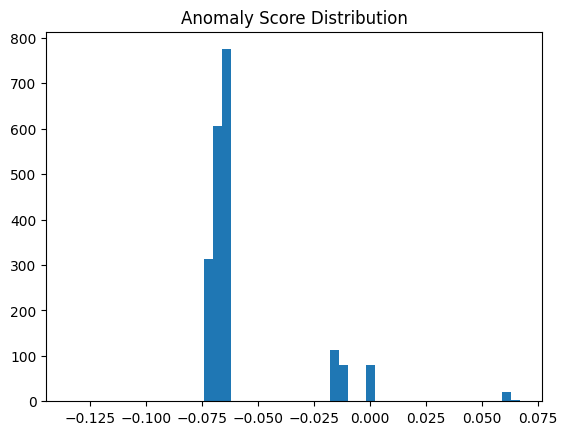

In [20]:
import matplotlib.pyplot as plt

plt.hist(results["anomaly_score"], bins=50)
plt.title("Anomaly Score Distribution")
plt.show()


In [23]:
import pandas as pd

# 1. Identify the exact features the model expects
expected_features = model.feature_names_in_

# 2. Create the fake block using ONLY those features
# This prevents 'anomaly' or other extra columns from sneaking in
fake_block = pd.DataFrame(0, index=[0], columns=expected_features)
fake_block["E1"] = 100
fake_block["E10"] = 80

# 3. Ensure your original X also only contains the expected features
# We use .copy() to avoid SettingWithCopy warnings
X_clean = X[expected_features].copy()

# 4. Combine them
X_test = pd.concat([X_clean, fake_block], ignore_index=True)

# 5. Calculate scores
# The negative sign is used because decision_function returns 
# lower values for outliers; negating it makes outliers have higher scores.
scores = -model.decision_function(X_test)

print("Score for fake block:", scores[-1])

Score for fake block: 0.0233195707759144


In [24]:
for seed in [1, 42, 99]:
    model = IsolationForest(
        n_estimators=200,
        contamination=0.05,
        random_state=seed
    )
    model.fit(X)
    print(seed, (-model.decision_function(X)).max())


1 0.04516338309190826
42 0.06666463710249815
99 0.06393024005482761


In [25]:
def ops_anomaly_detector(X, model):
    scores = -model.decision_function(X)
    idx = scores.argmax()
    return {
        "source": "ops",
        "entity": "hdfs_block",
        "block_id": X.index[idx],
        "anomaly_score": round(scores[idx], 2),
        "signal": "block_error_pattern"
    }


In [26]:
ops_anomaly_detector(X, model)


{'source': 'ops',
 'entity': 'hdfs_block',
 'block_id': 'blk_-1383276859207001328',
 'anomaly_score': 0.06,
 'signal': 'block_error_pattern'}

In [27]:
import joblib

joblib.dump(model, "ops_anomaly_model.joblib")
joblib.dump(X.columns.tolist(), "ops_features.joblib")


['ops_features.joblib']